<a href="https://colab.research.google.com/github/Vyshnavi262007/Assignment-3-AIML/blob/main/Customer_Segmentation_Using_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [3]:
# 2. Load dataset
df = pd.read_csv('/content/customer_segmentation_data.csv')

print("First 5 rows:")
print(df.head())


First 5 rows:
   Customer ID  Age  Gender Marital Status    Education Level  \
0        84966   23  Female        Married   Associate Degree   
1        95568   26    Male        Widowed          Doctorate   
2        10544   29  Female         Single   Associate Degree   
3        77033   20    Male       Divorced  Bachelor's Degree   
4        88160   25  Female      Separated  Bachelor's Degree   

  Geographic Information    Occupation  Income Level Behavioral Data  \
0                Mizoram  Entrepreneur       70541.0         policy5   
1                    Goa       Manager       54168.0         policy5   
2              Rajasthan  Entrepreneur       73899.0         policy5   
3                 Sikkim  Entrepreneur       63381.0         policy5   
4            West Bengal       Manager       38794.0         policy1   

  Purchase History Interactions with Customer Service  \
0       04-10-2018                              Phone   
1       11-06-2018                              

In [4]:
print("\nMissing values:")
print(df.isnull().sum())
# 3. Handle missing values
df = df.dropna()



Missing values:
Customer ID                           0
Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Geographic Information                1
Occupation                            1
Income Level                          1
Behavioral Data                       1
Purchase History                      1
Interactions with Customer Service    1
Insurance Products Owned              1
Coverage Amount                       1
Premium Amount                        1
Policy Type                           1
Customer Preferences                  1
Preferred Communication Channel       1
Preferred Contact Time                1
Preferred Language                    1
Segmentation Group                    1
dtype: int64


In [5]:
# 4. Select numeric columns
df_num = df.select_dtypes(include=np.number)
if 'Customer ID' in df_num.columns:
    df_num = df_num.drop(columns=['Customer ID'])

print("\nNumeric columns used:")
print(df_num.columns)


Numeric columns used:
Index(['Age', 'Income Level', 'Coverage Amount', 'Premium Amount'], dtype='object')


In [7]:
# 5. Feature Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_num)


In [8]:
# 6. Apply K-Means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)


In [9]:
# 7. Add cluster labels
df_num['Cluster'] = clusters

print("\nClustered Data:")
print(df_num.head())



Clustered Data:
   Age  Income Level  Coverage Amount  Premium Amount  Cluster
0   23       70541.0         366603.0          2749.0        1
1   26       54168.0         780236.0          1966.0        0
2   29       73899.0         773926.0          4413.0        1
3   20       63381.0         787815.0          4342.0        1
4   25       38794.0         366506.0          1276.0        0


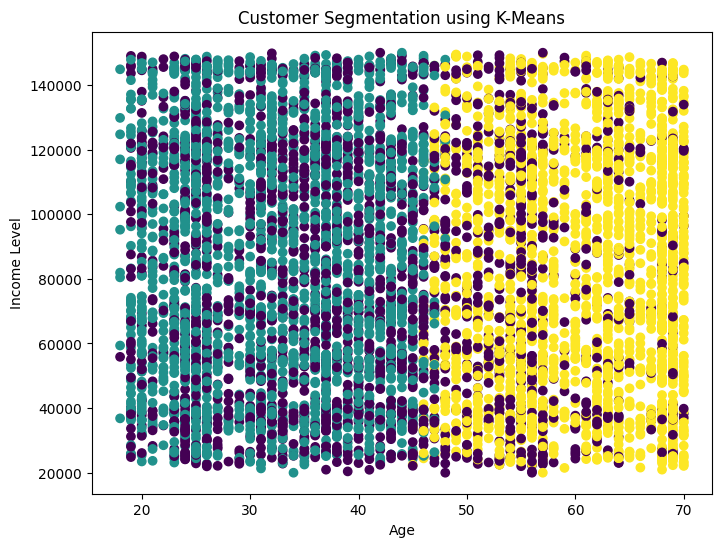

In [10]:
# 8. Visualization (first 2 features)
plt.figure(figsize=(8,6))
plt.scatter(df_num.iloc[:,0], df_num.iloc[:,1], c=clusters)
plt.xlabel(df_num.columns[0])
plt.ylabel(df_num.columns[1])
plt.title("Customer Segmentation using K-Means")
plt.show()

In [11]:
# 9. Clustering Evaluation Metrics
sil = silhouette_score(X_scaled, clusters)
ch = calinski_harabasz_score(X_scaled, clusters)
db = davies_bouldin_score(X_scaled, clusters)

print("\nEvaluation Metrics:")
print("Silhouette Score:", sil)
print("Calinski-Harabasz Score:", ch)
print("Davies-Bouldin Score:", db)


Evaluation Metrics:
Silhouette Score: 0.19526126149953726
Calinski-Harabasz Score: 1567.3440028268428
Davies-Bouldin Score: 1.6252600802925776


In [12]:
# 10. Find best K using Silhouette Score
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print(f"\nFor k = {k}")
    print("Silhouette Score:", silhouette_score(X_scaled, labels))


For k = 2
Silhouette Score: 0.197455446951326

For k = 3
Silhouette Score: 0.19526126149953726

For k = 4
Silhouette Score: 0.18887164493860606

For k = 5
Silhouette Score: 0.20402573869276042


In [14]:
from sklearn.metrics import confusion_matrix

# Actual labels
y_true = df['Segmentation Group']

# Convert y_true (string labels) to numerical labels
y_true_encoded, _ = pd.factorize(y_true)

# Predicted clusters
y_pred = clusters

cm = confusion_matrix(y_true_encoded, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[552 606 546   0   0]
 [360 385 339   0   0]
 [424 470 416   0   0]
 [411 480 427   0   0]
 [360 384 292   0   0]]


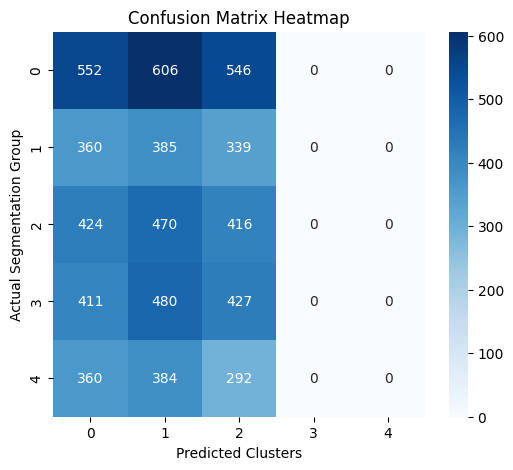

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Actual labels
y_true = df['Segmentation Group']

# Convert y_true (string labels) to numerical labels for confusion matrix
y_true_encoded, _ = pd.factorize(y_true)

# Predicted clusters
y_pred = clusters

# Confusion Matrix
cm = confusion_matrix(y_true_encoded, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Clusters")
plt.ylabel("Actual Segmentation Group")
plt.title("Confusion Matrix Heatmap")

plt.show()